<a href="https://colab.research.google.com/github/GasserElbanna/voice-speech-metamers/blob/deepfake/Deepfake_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install speechbrain

In [3]:
from collections import defaultdict

import torch
import torchaudio
import IPython
import os
import glob
import pandas as pd
import numpy as np
from transformers import Wav2Vec2Model
from transformers import WhisperProcessor, WhisperForConditionalGeneration
from speechbrain.inference.encoders import WaveformEncoder

In [4]:
%%capture
!pip install datasets -U
!pip install librosa
!pip install jiwer

https://huggingface.co/openai/whisper-medium

In [5]:
# prompt: mount my google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Whisper Analysis

In [ ]:
## list all the audios in the fake and real dataset
real_files_list = glob.glob('/content/drive/MyDrive/Deepfake_Analysis/AUDIO/REAL_PARSED/*.wav')
fake_files_list = glob.glob('/content/drive/MyDrive/Deepfake_Analysis/AUDIO/FAKE_PARSED/*.wav')

In [ ]:
# !pip install --upgrade pyarrow

In [ ]:
# load model and processor
processor = WhisperProcessor.from_pretrained("openai/whisper-base", language='en')
model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-base")
model.config.forced_decoder_ids = None


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/836k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.48M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/2.19k [00:00<?, ?B/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


config.json:   0%|          | 0.00/1.98k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/290M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/3.81k [00:00<?, ?B/s]

In [ ]:
transcript_real = pd.DataFrame()
transcript_fake = pd.DataFrame()

real_speech = []
fake_speech = []

target_length = 20 # number of seconds
sr = 16000
num_samples = int(target_length * sr)

resampler = torchaudio.transforms.Resample(44100, 16000)

for i in range(len(real_files_list)):
  real_audio, sr_audio = torchaudio.load(real_files_list[i])
  real_audio = resampler(real_audio)
  # Chop off the audio to target length
  input_real_audio = real_audio[0,:num_samples]
  input_features = processor(input_real_audio, sampling_rate=sr, return_tensors="pt").input_features
  predicted_ids = model.generate(input_features)
  # decode token ids to text
  transcription = processor.batch_decode(predicted_ids, skip_special_tokens=True)
  real_speech.append(transcription)


transcript_real['Audio_Name'] = real_files_list
transcript_real['Transcription'] = real_speech

for i in range(len(fake_files_list)):
  fake_audio, sr_audio = torchaudio.load(fake_files_list[i])
  fake_audio = resampler(fake_audio)
  # Chop off the audio to target length
  input_fake_audio = fake_audio[0,:num_samples]
  input_features = processor(input_fake_audio, sampling_rate=sr, return_tensors="pt").input_features
  predicted_ids = model.generate(input_features)
  # decode token ids to text
  transcription = processor.batch_decode(predicted_ids, skip_special_tokens=True)
  fake_speech.append(transcription)


transcript_fake['Audio_Name'] = fake_files_list
transcript_fake['Transcription'] = fake_speech




Due to a bug fix in https://github.com/huggingface/transformers/pull/28687 transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English.This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token.As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


In [ ]:
# prompt: create a new pandas dataframe

transcript_real.head()

,Audio_Name,Transcription
0,/content/drive/MyDrive/Deepfake_Analysis/AUDIO...,[ my fellow Americans. And the people abroad m...
1,/content/drive/MyDrive/Deepfake_Analysis/AUDIO...,"[ I see my buddy, Senator Tom Corporer down th..."
2,/content/drive/MyDrive/Deepfake_Analysis/AUDIO...,[ around him. Is that Ruth Ann? And that forme...
3,/content/drive/MyDrive/Deepfake_Analysis/AUDIO...,[ sisters law my sister Valerie anywhere folks...
4,/content/drive/MyDrive/Deepfake_Analysis/AUDIO...,"[ They've delivered us a clear victory, a conv..."


In [ ]:
transcript_fake.head()

,Audio_Name,Transcription
0,/content/drive/MyDrive/Deepfake_Analysis/AUDIO...,[ And I wouldn't be the man I am today without...
1,/content/drive/MyDrive/Deepfake_Analysis/AUDIO...,[ Let me say this public we Michelle]
2,/content/drive/MyDrive/Deepfake_Analysis/AUDIO...,[ I have never loved you more. I have never be...
3,/content/drive/MyDrive/Deepfake_Analysis/AUDIO...,[ Yay!]
4,/content/drive/MyDrive/Deepfake_Analysis/AUDIO...,[ Sasha Malia for our very eyes We're growing ...


In [ ]:
# prompt: how to save csv
transcript_real.to_csv('/content/drive/MyDrive/Deepfake_Analysis/AUDIO/transcript_real_snippets.csv', index=False)
transcript_fake.to_csv('/content/drive/MyDrive/Deepfake_Analysis/AUDIO/transcript_fake_snippets.csv', index=False)


In [ ]:
real_audio, sr = torchaudio.load('/content/drive/MyDrive/AUDIO/REAL/biden-original.wav')
fake_audio, sr = torchaudio.load('/content/drive/MyDrive/AUDIO/FAKE/biden-to-margot.wav')
resampler = torchaudio.transforms.Resample(sr, 16000)
real_audio = resampler(real_audio)
fake_audio = resampler(fake_audio)
sr = 16000

In [ ]:
target_length = 20 # number of seconds
num_samples = int(target_length * sr)
input_speech_real = real_audio[0,:num_samples]
input_speech_fake = fake_audio[0,:num_samples]
input_features_real = processor(input_speech_real, sampling_rate=sr, return_tensors="pt").input_features
input_features_fake = processor(input_speech_fake, sampling_rate=sr, return_tensors="pt").input_features

In [ ]:
# generate token ids
predicted_ids = model.generate(input_features_real)
# decode token ids to text
transcription = processor.batch_decode(predicted_ids, skip_special_tokens=False)

transcription_real = processor.batch_decode(predicted_ids, skip_special_tokens=True)

# generate token ids
predicted_ids = model.generate(input_features_fake)
# decode token ids to text
transcription = processor.batch_decode(predicted_ids, skip_special_tokens=False)

transcription_fake = processor.batch_decode(predicted_ids, skip_special_tokens=True)

In [ ]:
transcription_real

[' my fellow Americans and the people abroad me the dance Delawareans I see my buddy Tom Senator Tom Carpenter down there and I think Senator Kuhn']

In [ ]:
transcription_fake

[" my fellow Americans and the people of parliament dance, the Deleureans. I see my buddy, Senator Tom Carpardown there and I think Senator Coons is there and I think the governor's"]

# ECAPA-TDNN Analysis
#### https://huggingface.co/speechbrain/spkrec-ecapa-voxceleb

In [6]:
from speechbrain.inference.speaker import SpeakerRecognition
from speechbrain.inference.speaker import EncoderClassifier

In [7]:
verification = SpeakerRecognition.from_hparams(source="speechbrain/spkrec-ecapa-voxceleb", savedir="pretrained_models/spkrec-ecapa-voxceleb")


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


hyperparams.yaml:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

embedding_model.ckpt:   0%|          | 0.00/83.3M [00:00<?, ?B/s]

mean_var_norm_emb.ckpt:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

classifier.ckpt:   0%|          | 0.00/5.53M [00:00<?, ?B/s]

label_encoder.txt:   0%|          | 0.00/129k [00:00<?, ?B/s]

In [ ]:
## generate combinations of two files
# prompt: given a list of files how can i generate all the possible combinations of choosing two files

from itertools import combinations

def generate_combinations(file_list):
  """
  Generates all possible combinations of choosing two files from a list.

  Args:
    file_list: A list of file paths.

  Returns:
    A list of tuples, where each tuple contains two file paths.
  """
  return list(combinations(file_list, 2))

combinations_real = generate_combinations(real_files_list)
combinations_fake = generate_combinations(fake_files_list)

In [ ]:
speaker_verification_real = pd.DataFrame()

real_speakers = []
real_speakers_score = []

for i in range(len(combinations_real)):
  score, prediction = verification.verify_files(combinations_real[i][0], combinations_real[i][1])
  real_speakers.append(prediction)
  real_speakers_score.append(score)

speaker_verification_real['Audio_1'] = [x[0] for x in combinations_real]
speaker_verification_real['Audio_2'] = [x[1] for x in combinations_real]
speaker_verification_real['Are the two speakers same?'] = real_speakers
speaker_verification_real['Score'] = real_speakers_score


In [ ]:
speaker_verification_real.to_csv('/content/drive/MyDrive/Deepfake_Analysis/AUDIO/speaker_verification_real_snippet.csv', index=False)

In [ ]:
len(combinations_fake)

1540

In [ ]:
for i in range(len(fake_files_list)):
  fake_audio, sr_audio = torchaudio.load(fake_files_list[i])
  fake_audio = resampler(fake_audio)
  # Chop off the audio to target length
  input_fake_audio = fake_audio[0,:num_samples]
  input_features = processor(input_fake_audio, sampling_rate=sr, return_tensors="pt").input_features
  predicted_ids = model.generate(input_features)
  # decode token ids to text
  transcription = processor.batch_decode(predicted_ids, skip_special_tokens=True)
  fake_speech.append(transcription)

In [ ]:
speaker_verification_fake = pd.DataFrame()

fake_speakers = []
fake_speakers_score = []


target_length = 20 # number of seconds
sr = 16000
num_samples = int(target_length * sr)

resampler = torchaudio.transforms.Resample(44100, 16000)

for i in range(len(combinations_fake)):
# for i in range(250):
  if i % 100 == 0:
    print(i)
  fake_audio, sr_audio = torchaudio.load(combinations_fake[i][0])
  fake_audio = resampler(fake_audio)
  # Chop off the audio to target length
  input_audio_1 = fake_audio[0,:num_samples]
  fake_audio, sr_audio = torchaudio.load(combinations_fake[i][1])
  fake_audio = resampler(fake_audio)
  # Chop off the audio to target length
  input_audio_2 = fake_audio[0,:num_samples]
  score, prediction = verification.verify_batch(input_audio_1,input_audio_2)
  fake_speakers.append(prediction)
  fake_speakers_score.append(score)

speaker_verification_fake['Audio_1'] = [x[0] for x in combinations_fake]
speaker_verification_fake['Audio_2'] = [x[1] for x in combinations_fake]
speaker_verification_fake['Are the two speakers same?'] = fake_speakers
speaker_verification_fake['Score'] = fake_speakers_score


speaker_verification_fake.to_csv('/content/drive/MyDrive/AUDIO/speaker_verification_fake.csv', index=False)

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500


In [ ]:
speaker_verification_fake = pd.DataFrame()
speaker_verification_fake['Audio_1'] = [combinations_fake[i][0] for i in range(250)]
speaker_verification_fake['Audio_2'] = [combinations_fake[i][1] for i in range(250)]
speaker_verification_fake['Are the two speakers same?'] = fake_speakers
speaker_verification_fake['Score'] = fake_speakers_score


speaker_verification_fake.to_csv('/content/drive/MyDrive/AUDIO/speaker_verification_fake.csv', index=False)

In [ ]:
score, prediction = verification.verify_files("/content/drive/MyDrive/AUDIO/FAKE/biden-to-Obama.wav", "/content/drive/MyDrive/AUDIO/REAL/obama-original.wav") # Different Speakers

In [ ]:
## prediction is response to the question "are the two speakers same?"
prediction

tensor([True])

## Analyze results:

In [ ]:
transcript_real = pd.read_csv('/content/drive/MyDrive/Deepfake_Analysis/AUDIO/transcript_real.csv')
transcript_fake = pd.read_csv('/content/drive/MyDrive/Deepfake_Analysis/AUDIO/transcript_fake.csv')
speaker_verification_real = pd.read_csv('/content/drive/MyDrive/Deepfake_Analysis/AUDIO/speaker_verification_real.csv')
speaker_verification_fake = pd.read_csv('/content/drive/MyDrive/Deepfake_Analysis/AUDIO/speaker_verification_fake.csv')

In [ ]:
transcript_real['speaker'] = transcript_real['Audio_Name'].apply(lambda x: x.split('/')[-1].split('-')[0])
transcript_fake['true_speaker'] = transcript_fake['Audio_Name'].apply(lambda x: x.split('/')[-1].split('-')[0])
transcript_fake['fake_speaker'] = transcript_fake['Audio_Name'].apply(lambda x: x.split('/')[-1].split('-')[2].split('.')[0])

In [ ]:
transcript_real

,Audio_Name,Transcription,speaker
0,/content/drive/MyDrive/AUDIO/REAL/biden-origin...,[' my fellow Americans and the people abroad m...,biden
1,/content/drive/MyDrive/AUDIO/REAL/linus-origin...,"["" Most successful companies eventually outgro...",linus
2,/content/drive/MyDrive/AUDIO/REAL/margot-origi...,"["" Oh, okay. Brad couldn't be here tonight due...",margot
3,/content/drive/MyDrive/AUDIO/REAL/musk-origina...,"[' description. So I thought, I try to think, ...",musk
4,/content/drive/MyDrive/AUDIO/REAL/obama-origin...,"[' Tonight, more than 200 years after a former...",obama
5,/content/drive/MyDrive/AUDIO/REAL/ryan-origina...,"["" This isn't the first time I've been mistake...",ryan
6,/content/drive/MyDrive/AUDIO/REAL/taylor-origi...,"["" Absolutely love this one, right? This is so...",taylor
7,/content/drive/MyDrive/AUDIO/REAL/trump-origin...,"["" I've just received a call from Secretary Cl...",trump


In [ ]:
true_transcript = []

for i in range(len(transcript_fake)):
  spk = transcript_fake['true_speaker'][i]
  true_transcript.append(transcript_real[transcript_real['speaker'] == spk]['Transcription'].values)

In [ ]:
transcript_fake['true_transcript'] = true_transcript

In [ ]:
transcript_fake

,Audio_Name,Transcription,true_speaker,fake_speaker,true_transcript
0,/content/drive/MyDrive/AUDIO/FAKE/Obama-to-Bid...,"[' So now, more than 200 years after a former ...",Obama,Biden,[]
1,/content/drive/MyDrive/AUDIO/FAKE/Obama-to-Tru...,[' To know more than two hundred years after a...,Obama,Trump,[]
2,/content/drive/MyDrive/AUDIO/FAKE/biden-to-Oba...,"["" my fellow Americans. And the people will pr...",biden,Obama,[[' my fellow Americans and the people abroad ...
3,/content/drive/MyDrive/AUDIO/FAKE/biden-to-Tru...,"["" My fellow Americans. And the people who bro...",biden,Trump,[[' my fellow Americans and the people abroad ...
4,/content/drive/MyDrive/AUDIO/FAKE/biden-to-lin...,"["" my fellow Americans and the people who brou...",biden,linus,[[' my fellow Americans and the people abroad ...
5,/content/drive/MyDrive/AUDIO/FAKE/biden-to-mar...,"["" my fellow Americans and the people of parli...",biden,margot,[[' my fellow Americans and the people abroad ...
6,/content/drive/MyDrive/AUDIO/FAKE/biden-to-mus...,"["" my fellow Americans and the people of brawn...",biden,musk,[[' my fellow Americans and the people abroad ...
7,/content/drive/MyDrive/AUDIO/FAKE/biden-to-rya...,"["" my fellow Americans. People who are in the ...",biden,ryan,[[' my fellow Americans and the people abroad ...
8,/content/drive/MyDrive/AUDIO/FAKE/biden-to-tay...,"["" my fellow Americans and the people abroad m...",biden,taylor,[[' my fellow Americans and the people abroad ...
9,/content/drive/MyDrive/AUDIO/FAKE/linus-to-bid...,"["" Both successful companies eventually outgro...",linus,biden,"[["" Most successful companies eventually outgr..."


In [ ]:
# !pip install evaluate

In [ ]:
from jiwer import wer

result = {}

for i in range(len(transcript_fake)):
  try:
    val = wer(str(transcript_fake['true_transcript'].iloc[i]), str(transcript_fake['Transcription'].iloc[i]))
    result[i] = val
  except:
    pass

In [ ]:
len(transcript_fake)

56

In [ ]:
fakespeaker_wer_mapping = {'biden':[], 'obama':[], 'trump':[], 'linus':[], 'musk':[], 'ryan':[], 'taylor':[], 'margot':[]}
truespeaker_wer_mapping = {'biden':[], 'obama':[], 'trump':[], 'linus':[], 'musk':[], 'ryan':[], 'taylor':[], 'margot':[]}


for i in range(len(transcript_fake)):
  Spk = transcript_fake['fake_speaker'][i].lower()
  Spk_true = transcript_fake['true_speaker'][i].lower()
  val = wer(str(transcript_fake['true_transcript'].iloc[i]), str(transcript_fake['Transcription'].iloc[i]))
  fakespeaker_wer_mapping[Spk].append(val)
  truespeaker_wer_mapping[Spk_true].append(val)


In [ ]:
# plt.figure(figsize=(10, 6))
fakespeaker_wer_mapping_mean = {k: np.mean(v) for k, v in fakespeaker_wer_mapping.items()}
truespeaker_wer_mapping_mean = {k: np.mean(v) for k, v in truespeaker_wer_mapping.items()}


In [ ]:
fakespeaker_wer_mapping_mean

{'biden': 4.085758783127203,
 'obama': 0.35712192291139655,
 'trump': 4.253052503052503,
 'linus': 0.31712877765509345,
 'musk': 0.33316245158350416,
 'ryan': 0.3575503443924496,
 'taylor': 0.3012815644394592,
 'margot': 0.3486664407717039}

In [ ]:
truespeaker_wer_mapping_mean

{'biden': 0.6878306878306878,
 'obama': 8.082417582417584,
 'trump': 0.5519480519480519,
 'linus': 0.12433862433862432,
 'musk': 0.21804511278195488,
 'ryan': 0.29670329670329665,
 'taylor': 0.17063492063492064,
 'margot': 0.22180451127819548}

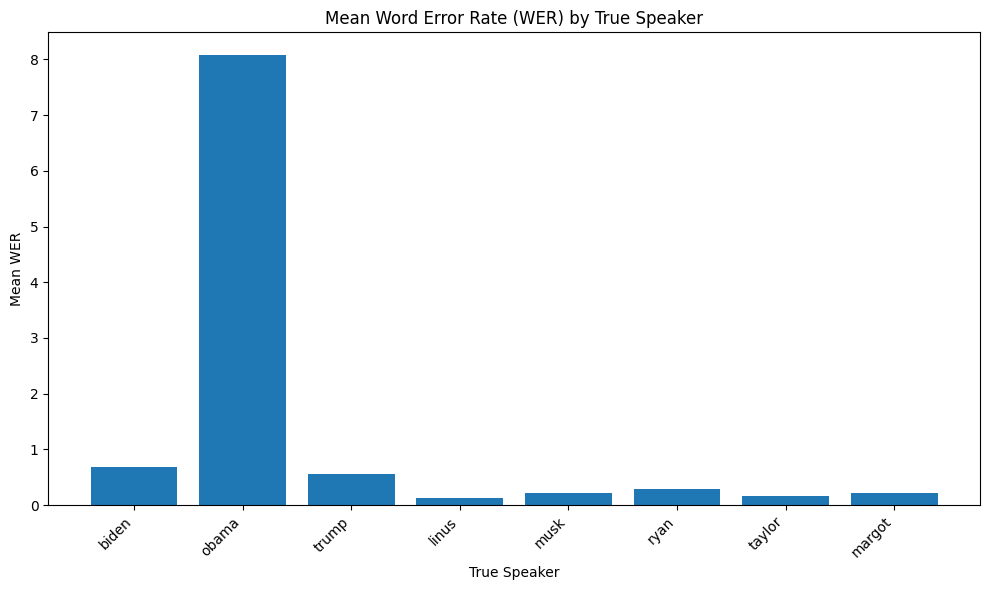

In [ ]:
# prompt: plot a bar chart for the data in truespeaker_wer_mapping_mean

import matplotlib.pyplot as plt

# Extract keys and values for plotting
speakers = list(truespeaker_wer_mapping_mean.keys())
wer_values = list(truespeaker_wer_mapping_mean.values())

# Create bar chart
plt.figure(figsize=(10, 6))
plt.bar(speakers, wer_values)
plt.xlabel('True Speaker')
plt.ylabel('Mean WER')
plt.title('Mean Word Error Rate (WER) by True Speaker')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


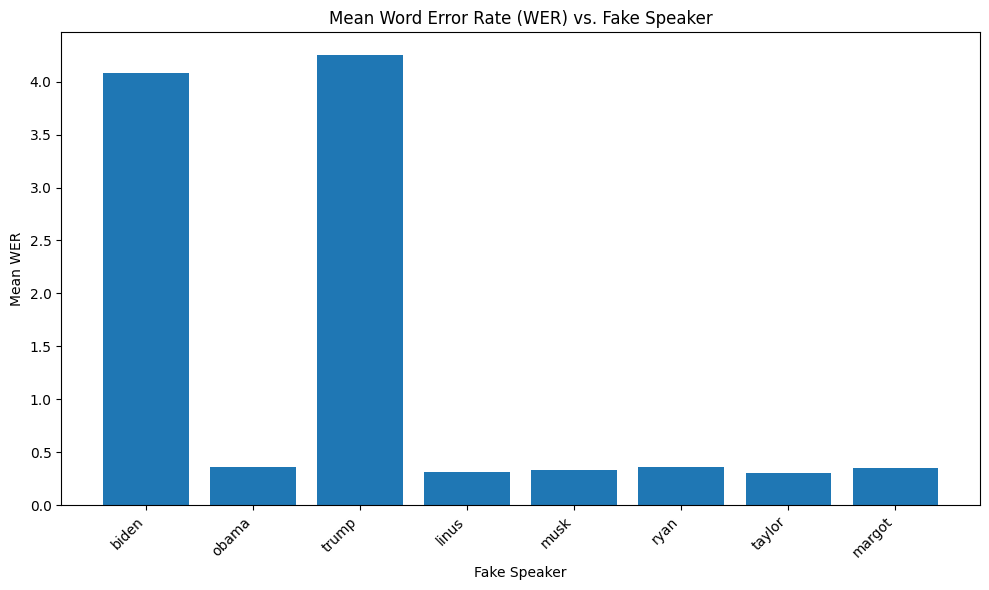

In [ ]:

# Extract keys and values for plotting
speakers = list(fakespeaker_wer_mapping_mean.keys())
wer_values = list(fakespeaker_wer_mapping_mean.values())

# Create bar chart
plt.figure(figsize=(10, 6))
plt.bar(speakers, wer_values)
plt.xlabel('Fake Speaker')
plt.ylabel('Mean WER')
plt.title('Mean Word Error Rate (WER) vs. Fake Speaker')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# from evaluate import load
# import evaluate
# wer = evaluate.load("wer")
# print(100 * wer.compute(references=transcript_fake['true_transcript'], predictions=transcript_fake['Transcription']))

Analysis of word error rate

In [ ]:
transcript_fake = pd.read_csv('/content/drive/MyDrive/Deepfake_Analysis/AUDIO/transcript_fake.csv')
reference_csv = pd.read_csv('/content/drive/MyDrive/Deepfake_Analysis/AUDIO/transcript_real.csv')

# from jiwer import wer

# result = {}

# for i in range(len(transcript_fake)):
#   try:
#     val = wer(str(transcript_fake['true_transcript'].iloc[i]), str(transcript_fake['Transcription'].iloc[i]))
#     result[i] = val
#   except:
#     pass

In [ ]:
hypothesis.head()

,Audio_Name,Transcription
0,/content/drive/MyDrive/Deepfake_Analysis/AUDIO...,"["" And I wouldn't be the man I am today withou..."
1,/content/drive/MyDrive/Deepfake_Analysis/AUDIO...,[' Let me say this public we Michelle']
2,/content/drive/MyDrive/Deepfake_Analysis/AUDIO...,"["" I have never loved you more. I have never b..."
3,/content/drive/MyDrive/Deepfake_Analysis/AUDIO...,[' Yay!']
4,/content/drive/MyDrive/Deepfake_Analysis/AUDIO...,"["" Sasha Malia for our very eyes We're growing..."
